centroids :  [[-2.58361866  9.03185632]
 [-6.88217395 -6.94243433]
 [ 4.70421356  1.99562444]]
=== K-Means 군집화 평가 결과 (K=3) ===
1. Inertia (군집 내 SSE)         : 204.0694
2. 실루엣 계수 (Silhouette Score) : 0.9084 (1에 가까울수록 양호)
3. Calinski-Harabasz Index     : 14321.2470 (높을수록 양호)
4. Davies-Bouldin Index        : 0.1281 (0에 가까울수록 양호)
---------------------------------------------


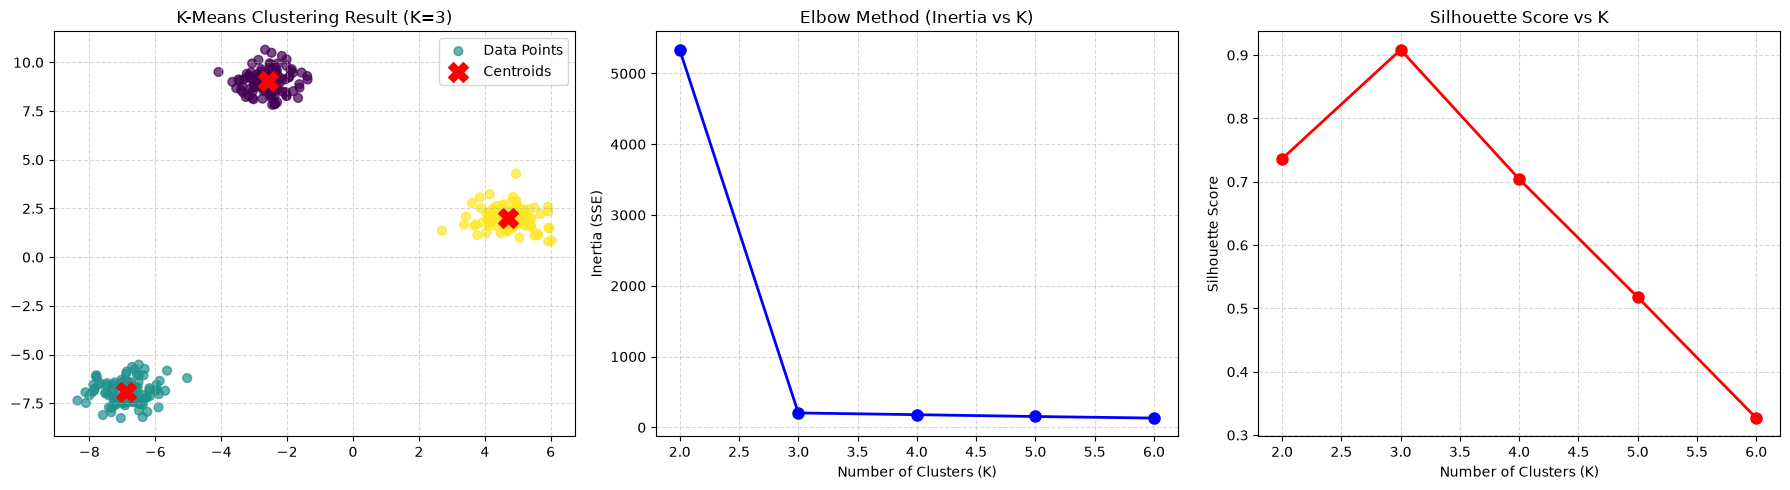

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

# 1. 가상 데이터셋 생성 (3개 군집, 2차원 공간)
X, y_true = make_blobs(
    n_samples=300, centers=3, cluster_std=0.60, random_state=42
)

# 2. K-Means 모델 정의 및 학습 (K=3, K-Means++ 초기화)
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

print("centroids : ", centroids)

# ==================================================
# 3. 단일 K(K=3)에 대한 평가 지표 계산
# ==================================================
inertia = kmeans.inertia_  # 군집 내 오차제곱합 (SSE)
sil_score = silhouette_score(X, labels)
ch_score = calinski_harabasz_score(X, labels)
db_score = davies_bouldin_score(X, labels)

print("=== K-Means 군집화 평가 결과 (K=3) ===")
print(f"1. Inertia (군집 내 SSE)         : {inertia:.4f}")
print(f"2. 실루엣 계수 (Silhouette Score) : {sil_score:.4f} (1에 가까울수록 양호)")
print(f"3. Calinski-Harabasz Index     : {ch_score:.4f} (높을수록 양호)")
print(f"4. Davies-Bouldin Index        : {db_score:.4f} (0에 가까울수록 양호)")
print("-" * 45)

# ==================================================
# 4. 최적 K 탐색 (Elbow Method & Silhouette Analysis)
# ==================================================
inertias = []
sil_scores = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    cluster_labels = km.fit_predict(X)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, cluster_labels))

# 5. 시각화 (군집 결과 + 엘보우 그래프 + 실루엣 변화)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) K=3 군집화 산점도
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=40,
    cmap="viridis",
    alpha=0.7,
    label="Data Points",
)
axes[0].scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="red",
    s=200,
    marker="X",
    label="Centroids",
)
axes[0].set_title("K-Means Clustering Result (K=3)", fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# (2) Elbow Method (Inertia vs K)
axes[1].plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
axes[1].set_title("Elbow Method (Inertia vs K)", fontsize=12)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Inertia (SSE)")
axes[1].grid(True, linestyle="--", alpha=0.5)

# (3) Silhouette Score vs K
axes[2].plot(K_range, sil_scores, "ro-", linewidth=2, markersize=8)
axes[2].set_title("Silhouette Score vs K", fontsize=12)
axes[2].set_xlabel("Number of Clusters (K)")
axes[2].set_ylabel("Silhouette Score")
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

--- 원본 데이터 상위 5개 항목 ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
--------------------------------------------------


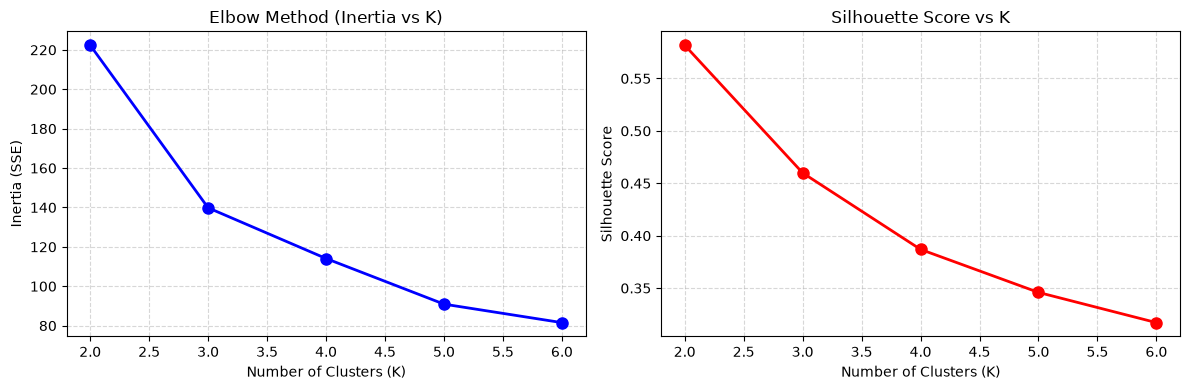

=== 최종 K-Means 평가 결과 (K=3) ===
1. Inertia (군집 내 SSE)         : 139.8205
2. 실루엣 계수 (Silhouette Score) : 0.4599 (1에 가까울수록 양호)
3. Calinski-Harabasz Index     : 241.9044 (높을수록 양호)
4. Davies-Bouldin Index        : 0.8336 (0에 가까울수록 양호)
--------------------------------------------------


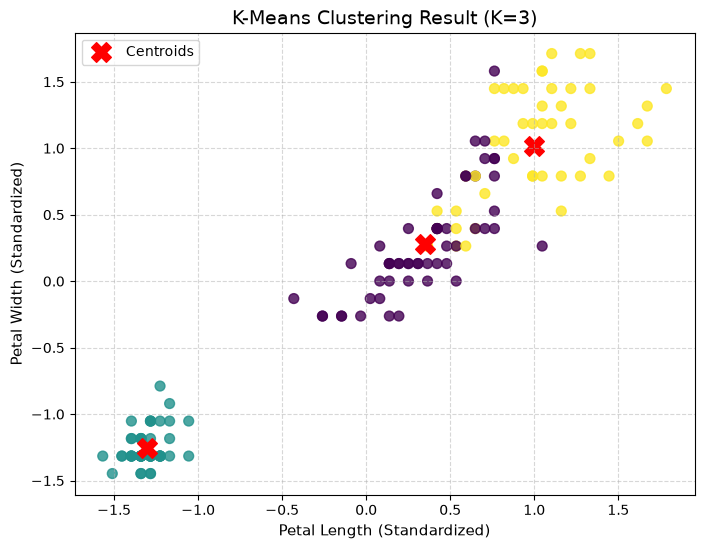

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

# ==================================================
# 1. 데이터 로드 및 확인
# ==================================================
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Pandas DataFrame으로 변환
df = pd.DataFrame(X, columns=feature_names)
print("--- 원본 데이터 상위 5개 항목 ---")
print(df.head())
print("-" * 50)

# ==================================================
# 2. 데이터 전처리 (StandardScaler)
# ==================================================
# 거리 기반 알고리즘 특성상 변수 간 스케일 차이가 크면 거리가 편향됩니다.
# 평균 0, 표준편차 1로 맞춰주는 표준화(Standardization) 작업 필수!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==================================================
# 3. 최적의 K(군집 수) 탐색 (Elbow Method & Silhouette Score)
# ==================================================
inertias = []
sil_scores = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# 최적 K 탐색 그래프 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow Method
axes[0].plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
axes[0].set_title("Elbow Method (Inertia vs K)")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Silhouette Score
axes[1].plot(K_range, sil_scores, "ro-", linewidth=2, markersize=8)
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ==================================================
# 4. 최종 K-Means 모델 생성 및 학습 (K=3 선택)
# ==================================================
best_k = 3
final_kmeans = KMeans(
    n_clusters=best_k, init="k-means++", n_init=10, random_state=42
)
final_labels = final_kmeans.fit_predict(X_scaled)
centroids = final_kmeans.cluster_centers_

# 결과를 DataFrame에 추가
df["Cluster"] = final_labels

# ==================================================
# 5. 모델 평가 (Evaluation Metrics)
# ==================================================
sil = silhouette_score(X_scaled, final_labels)
ch = calinski_harabasz_score(X_scaled, final_labels)
db = davies_bouldin_score(X_scaled, final_labels)

print(f"=== 최종 K-Means 평가 결과 (K={best_k}) ===")
print(f"1. Inertia (군집 내 SSE)         : {final_kmeans.inertia_:.4f}")
print(f"2. 실루엣 계수 (Silhouette Score) : {sil:.4f} (1에 가까울수록 양호)")
print(f"3. Calinski-Harabasz Index     : {ch:.4f} (높을수록 양호)")
print(f"4. Davies-Bouldin Index        : {db:.4f} (0에 가까울수록 양호)")
print("-" * 50)

# ==================================================
# 6. 군집화 결과 시각화 (2개 주요 특성 기준)
# ==================================================
plt.figure(figsize=(8, 6))

# 꽃잎 길이(Petal Length)와 꽃잎 너비(Petal Width) 특성을 기준으로 산점도 생성
plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=final_labels,
    cmap="viridis",
    s=50,
    alpha=0.8,
)
plt.scatter(
    centroids[:, 2],
    centroids[:, 3],
    c="red",
    s=200,
    marker="X",
    label="Centroids",
)

plt.title(f"K-Means Clustering Result (K={best_k})", fontsize=14)
plt.xlabel("Petal Length (Standardized)", fontsize=11)
plt.ylabel("Petal Width (Standardized)", fontsize=11)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

=== 군집화 평가 결과 비교 ===
DBSCAN  -> ARI (정답 일치도): 1.0000 | Silhouette Score: 0.3803
K-Means -> ARI (정답 일치도): 0.4790 | Silhouette Score: 0.4936
-------------------------------------------------------
DBSCAN 형성된 군집 수 : 2개
DBSCAN 감지된 노이즈 개수: 0개


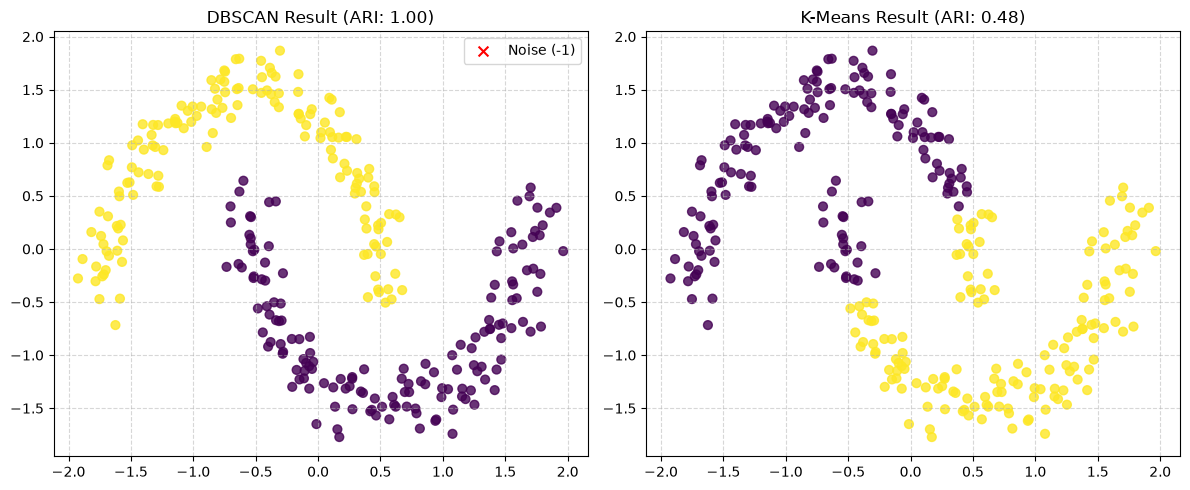

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. 초승달 모양(make_moons) 비구형 데이터 생성
X, y_true = make_moons(n_samples=300, noise=0.08, random_state=42)

# 2. 데이터 전처리 (StandardScaler)
# 밀도/거리 기반 알고리즘이므로 스케일링을 반드시 진행합니다.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 모델 생성 및 학습
# DBSCAN (eps: 탐색 반경, min_samples: 최소 이웃 수)
dbscan = DBSCAN(eps=0.3, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

# K-Means (비교용)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

# ==================================================
# 4. 군집화 평가 (Evaluation)
# ==================================================
# (1) ARI (Adjusted Rand Index): 실제 정답 라벨과 얼마나 일치하는지 평가 (1에 가까울수록 완벽)
ari_db = adjusted_rand_score(y_true, db_labels)
ari_km = adjusted_rand_score(y_true, km_labels)

# (2) Silhouette Score: 노이즈(-1) 포인트를 제외한 순수 군집 데이터로 계산
mask = db_labels != -1
sil_db = silhouette_score(X_scaled[mask], db_labels[mask])
sil_km = silhouette_score(X_scaled, km_labels)

print("=== 군집화 평가 결과 비교 ===")
print(
    f"DBSCAN  -> ARI (정답 일치도): {ari_db:.4f} | Silhouette Score:"
    f" {sil_db:.4f}"
)
print(
    f"K-Means -> ARI (정답 일치도): {ari_km:.4f} | Silhouette Score:"
    f" {sil_km:.4f}"
)
print("-" * 55)
print(
    f"DBSCAN 형성된 군집 수 : {len(set(db_labels)) - (1 if -1 in db_labels else 0)}개"
)
print(f"DBSCAN 감지된 노이즈 개수: {list(db_labels).count(-1)}개")

# ==================================================
# 5. 결과 시각화 비교
# ==================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (1) DBSCAN 결과 시각화
axes[0].scatter(
    X_scaled[db_labels != -1, 0],
    X_scaled[db_labels != -1, 1],
    c=db_labels[db_labels != -1],
    cmap="viridis",
    s=40,
    alpha=0.8,
)
axes[0].scatter(
    X_scaled[db_labels == -1, 0],
    X_scaled[db_labels == -1, 1],
    c="red",
    marker="x",
    s=50,
    label="Noise (-1)",
)
axes[0].set_title(f"DBSCAN Result (ARI: {ari_db:.2f})")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# (2) K-Means 결과 시각화
axes[1].scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=km_labels,
    cmap="viridis",
    s=40,
    alpha=0.8,
)
axes[1].set_title(f"K-Means Result (ARI: {ari_km:.2f})")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

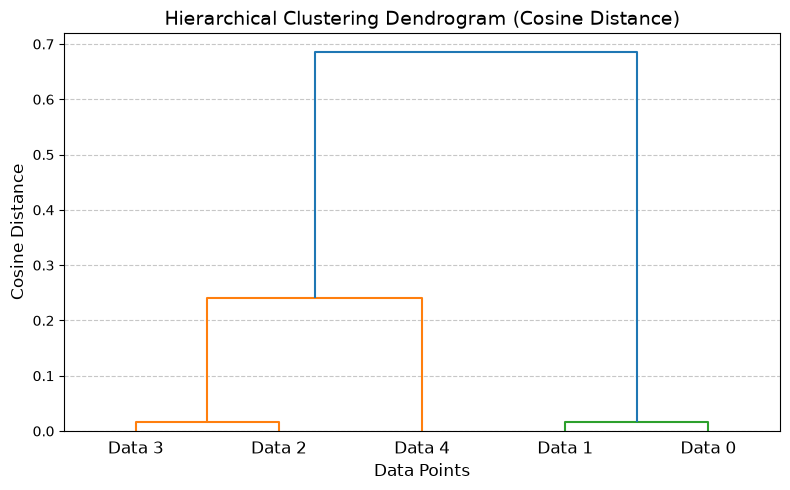

--- 군집화 결과 ---
Data 0 -> Cluster 1
Data 1 -> Cluster 1
Data 2 -> Cluster 2
Data 3 -> Cluster 2
Data 4 -> Cluster 2


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist

# 1. 샘플 데이터 생성 (5개의 문서 또는 아이템의 특징 벡터)
# 코사인 거리는 방향성이 중요하므로 스파스(Sparse)하거나 고차원 특성 벡터에 유용합니다.
data = np.array(
    [
        [1.0, 0.9, 0.0, 0.0],  # 데이터 0 (A그룹 유사)
        [0.8, 1.0, 0.1, 0.0],  # 데이터 1 (A그룹 유사)
        [0.1, 0.0, 0.9, 1.0],  # 데이터 2 (B그룹 유사)
        [0.0, 0.2, 0.8, 0.9],  # 데이터 3 (B그룹 유사)
        [0.5, 0.5, 0.5, 0.5],  # 데이터 4 (중간 특성)
    ]
)

labels = ["Data 0", "Data 1", "Data 2", "Data 3", "Data 4"]

# 2. 코사인 거리 행렬(Distance Matrix) 계산
# metric='cosine'을 지정하여 코사인 거리를 계산합니다.
# 코사인 거리 = 1 - 코사인 유사도
distance_matrix = pdist(data, metric="cosine")

# 3. 계층적 군집화 수행 (Linkage 계산)
# 와드(Ward)법은 유클리드 거리만 지원하므로,
# 코사인 거리 사용 시 'average', 'complete', 'single' 등의 연결법을 사용합니다.
Z = linkage(distance_matrix, method="average")

# 4. 덴드로그램 시각화
plt.figure(figsize=(8, 5))
dendrogram(Z, labels=labels, orientation="top", distance_sort="descending")

plt.title("Hierarchical Clustering Dendrogram (Cosine Distance)", fontsize=14)
plt.xlabel("Data Points", fontsize=12)
plt.ylabel("Cosine Distance", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 5. 특정 거리 임계값(Threshold) 또는 군집 수 기준으로 클러스터 라벨 추출
# 예: 코사인 거리가 0.5 이하인 것끼리 묶기
max_d = 0.5
clusters = fcluster(Z, criterion="distance", t=max_d)

print("--- 군집화 결과 ---")
for label, cluster_id in zip(labels, clusters):
  print(f"{label} -> Cluster {cluster_id}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

# 1. 샘플 데이터 생성
data = np.array(
    [
        [1.0, 0.9, 0.0, 0.0],  # 데이터 0 (A그룹 유사)
        [0.8, 1.0, 0.1, 0.0],  # 데이터 1 (A그룹 유사)
        [0.1, 0.0, 0.9, 1.0],  # 데이터 2 (B그룹 유사)
        [0.0, 0.2, 0.8, 0.9],  # 데이터 3 (B그룹 유사)
        [0.5, 0.5, 0.5, 0.5],  # 데이터 4 (중간 특성)
    ]
)
labels = ["Data 0", "Data 1", "Data 2", "Data 3", "Data 4"]

# 2. 코사인 거리 계산 및 계층적 군집화
distance_matrix = pdist(data, metric="cosine")
Z = linkage(distance_matrix, method="average")

# 3. 임계값(t=0.5) 기준으로 군집 라벨 추출
max_d = 0.5
clusters = fcluster(Z, criterion="distance", t=max_d)

print("--- 군집 할당 결과 ---")
for label, cluster_id in zip(labels, clusters):
  print(f"{label} -> Cluster {cluster_id}")
print("-" * 30)

# ==================================================
# 4. 군집화 평가 지표 계산 (Evaluation)
# ==================================================
# 평가 지표 산출을 위해서는 최소 2개 이상, 데이터 개수 미만의 군집이 필요합니다.
num_clusters = len(set(clusters))

if 1 < num_clusters < len(data):
  # (1) 실루엣 계수 (Silhouette Score) - 코사인 거리 지정 필수
  sil_score = silhouette_score(data, clusters, metric="cosine")

  # (2) Calinski-Harabasz 지수 (Variance Ratio Criterion)
  ch_score = calinski_harabasz_score(data, clusters)

  # (3) Davies-Bouldin 지수
  db_score = davies_bouldin_score(data, clusters)

  print("=== 군집화 평가 지표 결과 ===")
  print(f"1. 실루엣 계수 (Silhouette Score)    : {sil_score:.4f}")
  print(f"2. Calinski-Harabasz Index           : {ch_score:.4f}")
  print(f"3. Davies-Bouldin Index              : {db_score:.4f}")
else:
  print(
      f"현재 형성된 군집 수({num_clusters}개)가 평가 기준을 충족하지 않습니다."
  )

--- 군집 할당 결과 ---
Data 0 -> Cluster 1
Data 1 -> Cluster 1
Data 2 -> Cluster 2
Data 3 -> Cluster 2
Data 4 -> Cluster 2
------------------------------
=== 군집화 평가 지표 결과 ===
1. 실루엣 계수 (Silhouette Score)    : 0.7595
2. Calinski-Harabasz Index           : 14.5185
3. Davies-Bouldin Index              : 0.3486
